In [2]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Other ML
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import skew, kurtosis
from kneed import KneeLocator

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 120
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [3]:
# Load dataset — update path if needed
df = pd.read_csv('D:\\Projects\\Fifa20\\players_20.csv', low_memory=False)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (18278, 104)


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,...,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,94,94,95500000,565000,"RW, CF, ST",Left,5,4,4,Medium/Low,Messi,Yes,195800000.00,"#Dribbler, #Distance Shooter, #Crosser, #FK Sp...",RW,10.00,NaN,2004-07-01,2021.00,NaN,...,11,15,14,8,89+2,89+2,89+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,92+2,87+2,87+2,87+2,92+2,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,93,93,58500000,405000,"ST, LW",Right,5,4,5,High/Low,C. Ronaldo,Yes,96500000.00,"#Speedster, #Dribbler, #Distance Shooter, #Acr...",LW,7.00,NaN,2018-07-10,2022.00,LS,...,11,15,14,11,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,88+3,88+3,88+3,81+3,81+3,81+3,88+3,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,92,92,105500000,290000,"LW, CAM",Right,5,5,5,High/Medium,Neymar,Yes,195200000.00,"#Speedster, #Dribbler, #Playmaker , #Crosser,...",CAM,10.00,NaN,2017-08-03,2022.00,LW,...,9,15,15,11,84+3,84+3,84+3,90+3,89+3,89+3,89+3,90+3,90+3,90+3,90+3,89+3,82+3,82+3,82+3,89+3,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3


In [4]:
print('='*60)
print('📋 DATASET OVERVIEW')
print('='*60)
print(f'Rows       : {df.shape[0]:,}')
print(f'Columns    : {df.shape[1]}')
print(f'Memory     : {df.memory_usage(deep=True).sum()/1024**2:.2f} MB')
print()
print('--- Data Types ---')
print(df.dtypes.value_counts())
print()
print('--- Missing Values (Top 15) ---')
missing = df.isnull().sum()
print(missing[missing>0].sort_values(ascending=False).head(15))

📋 DATASET OVERVIEW
Rows       : 18,278
Columns    : 104
Memory     : 48.13 MB

--- Data Types ---
int64      45
str        43
float64    16
Name: count, dtype: int64

--- Missing Values (Top 15) ---
loaned_from             17230
nation_position         17152
nation_jersey_number    17152
player_tags             16779
gk_diving               16242
gk_reflexes             16242
gk_kicking              16242
gk_handling             16242
gk_speed                16242
gk_positioning          16242
player_traits           10712
dribbling                2036
defending                2036
shooting                 2036
pace                     2036
dtype: int64


In [5]:
print('--- Descriptive Statistics (Numeric) ---')
df.describe().T

--- Descriptive Statistics (Numeric) ---


,count,mean,std,min,25%,50%,75%,max
sofifa_id,18278.00,219738.86,27960.20,768.00,204445.50,226165.00,240795.75,252905.00
age,18278.00,25.28,4.66,16.00,22.00,25.00,29.00,42.00
height_cm,18278.00,181.36,6.76,156.00,177.00,181.00,186.00,205.00
weight_kg,18278.00,75.28,7.05,50.00,70.00,75.00,80.00,110.00
overall,18278.00,66.24,6.95,48.00,62.00,66.00,71.00,94.00
...,...,...,...,...,...,...,...,...
goalkeeping_diving,18278.00,16.57,17.74,1.00,8.00,11.00,14.00,90.00
goalkeeping_handling,18278.00,16.35,17.00,1.00,8.00,11.00,14.00,92.00
goalkeeping_kicking,18278.00,16.21,16.61,1.00,8.00,11.00,14.00,93.00
goalkeeping_positioning,18278.00,16.37,17.14,1.00,8.00,11.00,14.00,91.00


In [6]:
# Wage / Value cleaning helper
def parse_currency(val):
    if pd.isna(val): return np.nan
    val = str(val).replace('€','').replace(',','')
    if 'M' in val: return float(val.replace('M',''))*1_000_000
    if 'K' in val: return float(val.replace('K',''))*1_000
    try: return float(val)
    except: return np.nan

for col in ['value_eur','wage_eur','release_clause_eur']:
    if col in df.columns:
        df[col] = df[col].apply(parse_currency)

# Height to cm
def height_to_cm(h):
    try:
        parts = str(h).split("'")
        return int(parts[0])*30.48 + int(parts[1].replace('"','').strip())*2.54
    except:
        try: return float(h)
        except: return np.nan

if df['height_cm'].dtype == object:
    df['height_cm'] = df['height_cm'].apply(height_to_cm)

print('✅ Currency and height columns cleaned.')

✅ Currency and height columns cleaned.


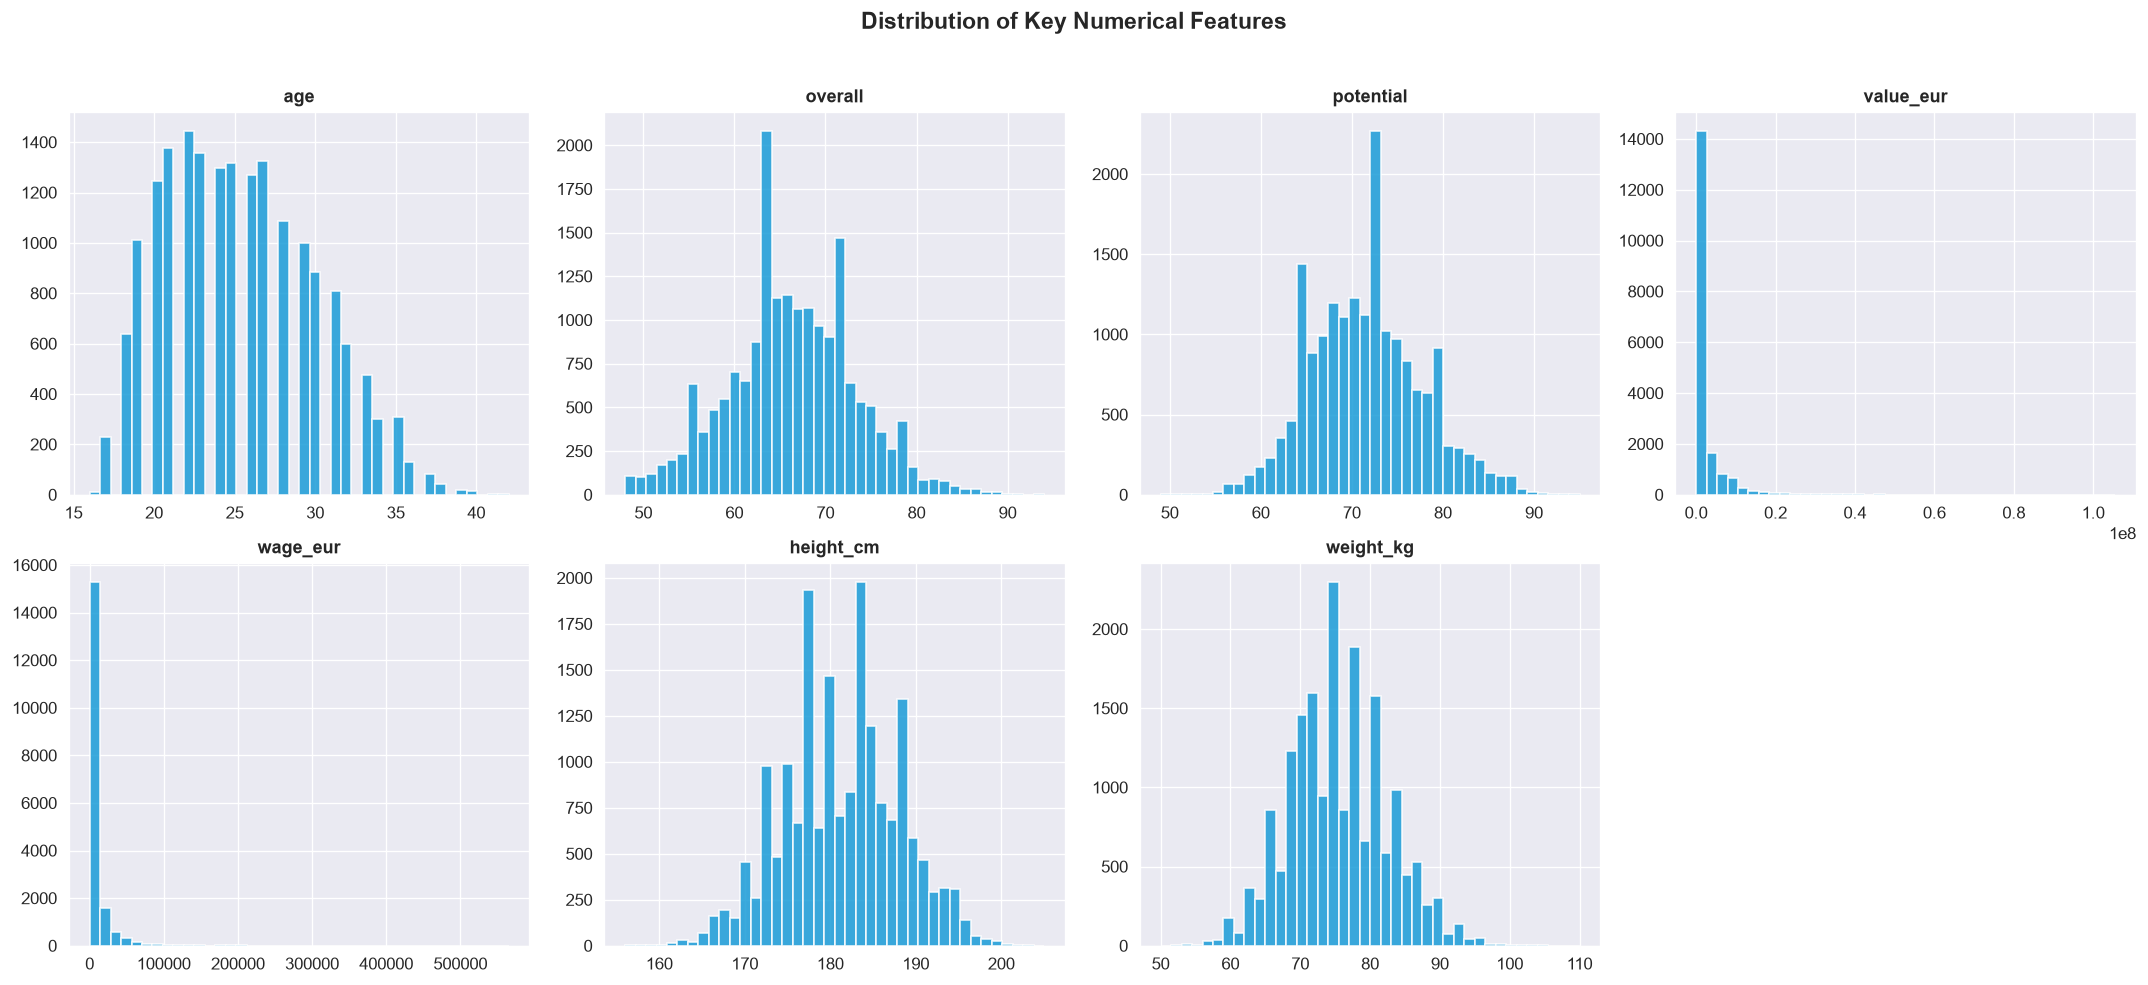

In [7]:
# ---- Distribution Plots ----
num_cols = ['age','overall','potential','value_eur','wage_eur','height_cm','weight_kg']
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(2, len(num_cols)//2+1, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='#1a9cd8', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Distribution of Key Numerical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight')
plt.show()

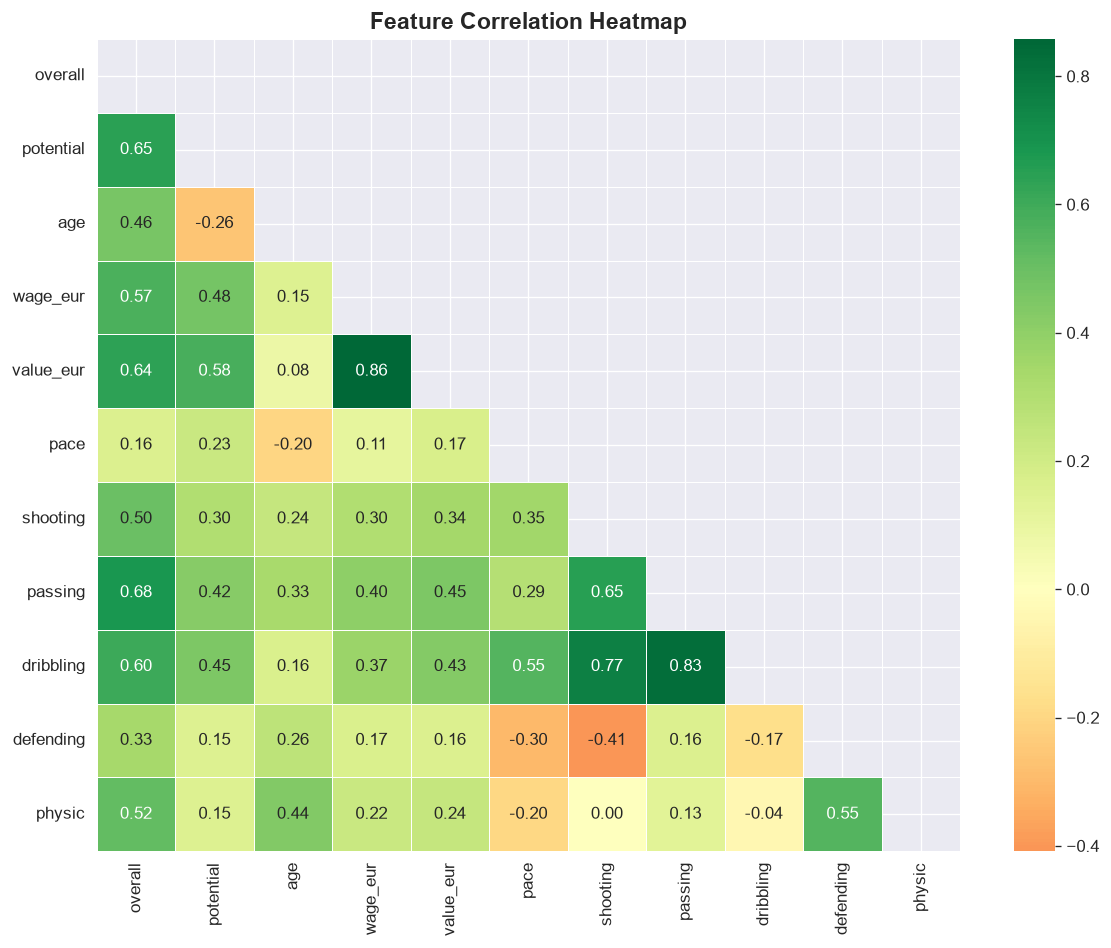

In [8]:
# Correlation Heatmap
skill_cols = ['pace','shooting','passing','dribbling','defending','physic'] if 'pace' in df.columns else []
attr_cols = ['overall','potential','age','wage_eur','value_eur'] + skill_cols
attr_cols = [c for c in attr_cols if c in df.columns]

corr = df[attr_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

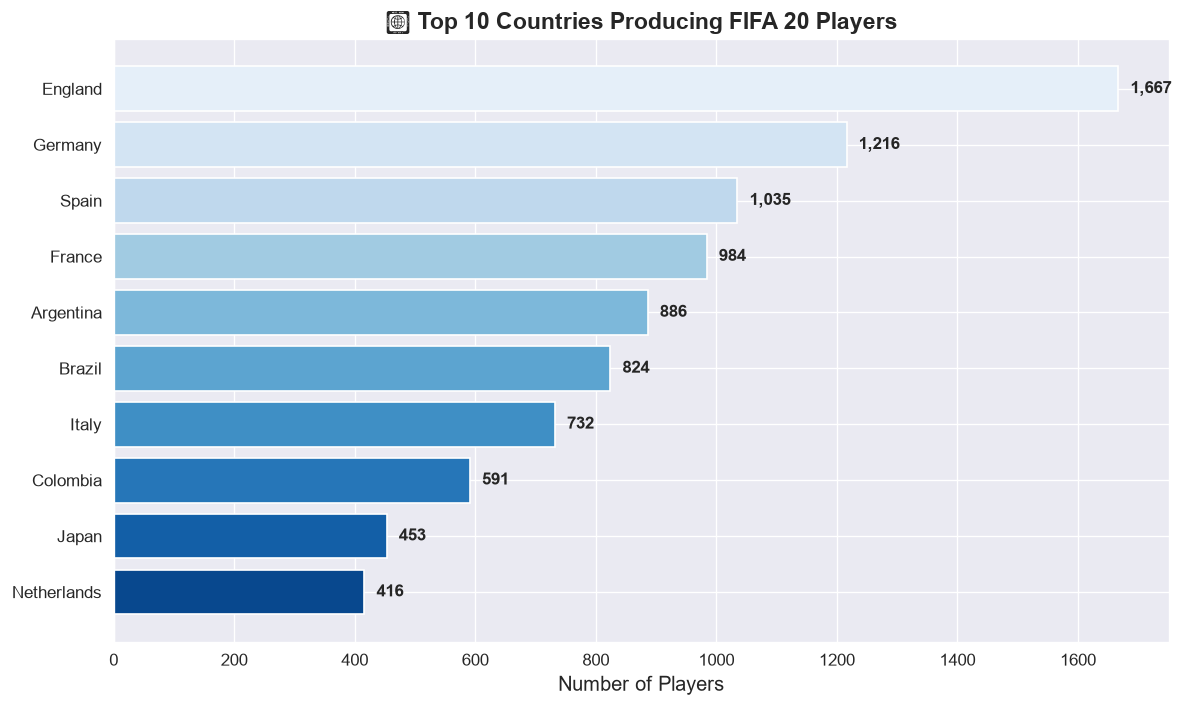

    Country  Player Count
    England          1667
    Germany          1216
      Spain          1035
     France           984
  Argentina           886
     Brazil           824
      Italy           732
   Colombia           591
      Japan           453
Netherlands           416


In [9]:
nat_col = 'nationality' if 'nationality' in df.columns else 'nationality_name'
top10 = df[nat_col].value_counts().head(10).reset_index()
top10.columns = ['Country','Player Count']
top10 = top10.sort_values('Player Count')

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Blues_r', len(top10))
bars = ax.barh(top10['Country'], top10['Player Count'], color=colors, edgecolor='white')
for bar, val in zip(bars, top10['Player Count']):
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2, f'{val:,}',
            va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Number of Players', fontsize=12)
ax.set_title('🌍 Top 10 Countries Producing FIFA 20 Players', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top10_countries.png', bbox_inches='tight')
plt.show()
print(top10.sort_values('Player Count',ascending=False).to_string(index=False))

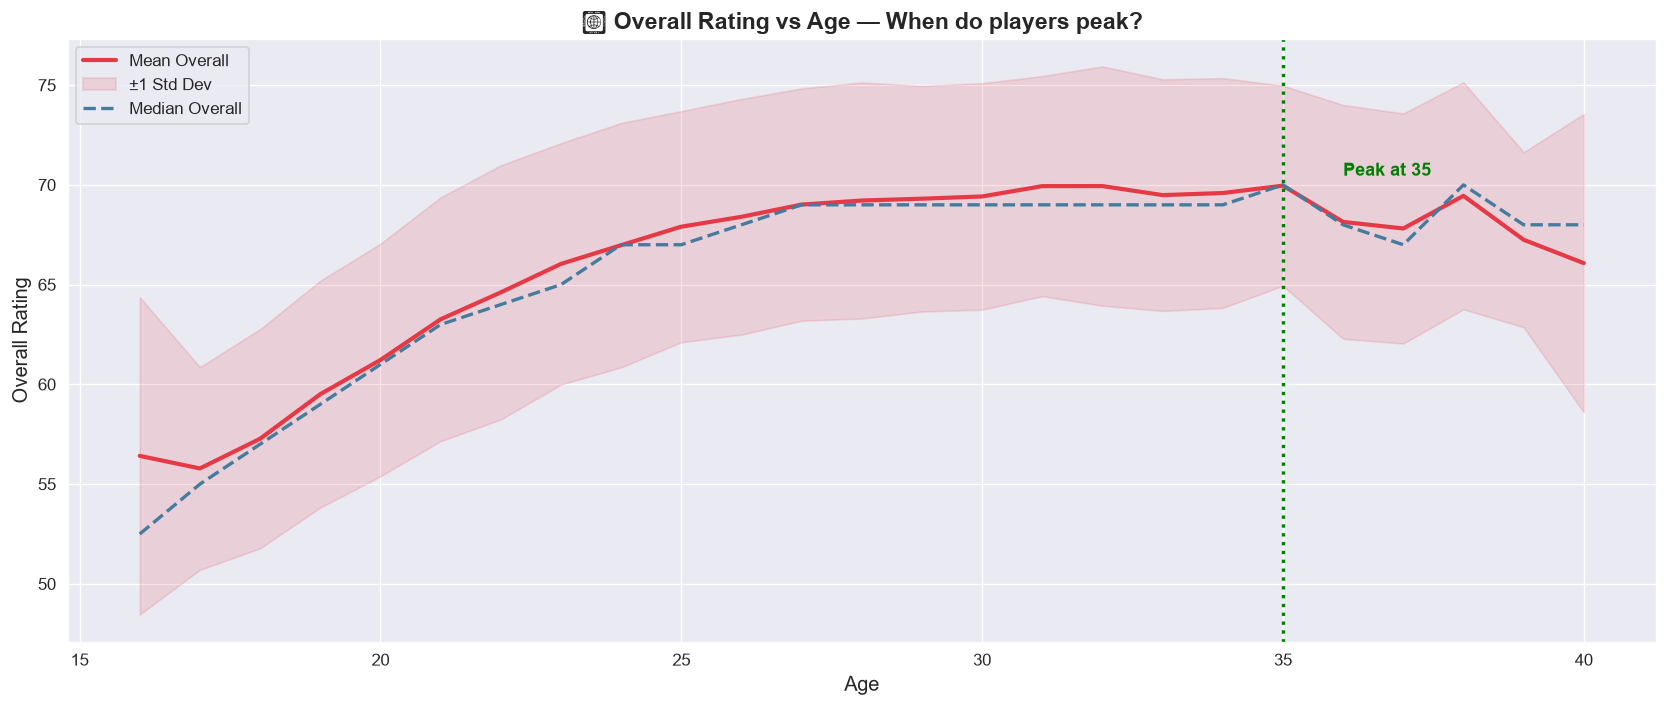

📌 Peak improvement age  : 35
📌 Rating starts declining after age : ~34


In [10]:
age_overall = df.groupby('age')['overall'].agg(['mean','median','std','count']).reset_index()
age_overall.columns = ['age','mean_overall','median_overall','std_overall','count']
age_overall = age_overall[age_overall['count'] >= 10]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(age_overall['age'], age_overall['mean_overall'], color='#e63946', lw=2.5, label='Mean Overall')
ax.fill_between(age_overall['age'],
                age_overall['mean_overall'] - age_overall['std_overall'],
                age_overall['mean_overall'] + age_overall['std_overall'],
                alpha=0.15, color='#e63946', label='±1 Std Dev')
ax.plot(age_overall['age'], age_overall['median_overall'], color='#457b9d', lw=2,
        linestyle='--', label='Median Overall')

# Find peak
peak_age = age_overall.loc[age_overall['mean_overall'].idxmax(), 'age']
peak_val = age_overall['mean_overall'].max()
ax.axvline(x=peak_age, color='green', linestyle=':', lw=2)
ax.annotate(f'Peak at {peak_age}', xy=(peak_age, peak_val),
            xytext=(peak_age+1, peak_val+0.5), fontsize=11, color='green', fontweight='bold')

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Overall Rating', fontsize=12)
ax.set_title('📈 Overall Rating vs Age — When do players peak?', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('overall_vs_age.png', bbox_inches='tight')
plt.show()

# Decline point analysis
roll_mean = age_overall.set_index('age')['mean_overall'].rolling(3).mean().dropna()
decline_age = (roll_mean.diff() < 0).idxmax()
print(f'📌 Peak improvement age  : {peak_age}')
print(f'📌 Rating starts declining after age : ~{decline_age}')

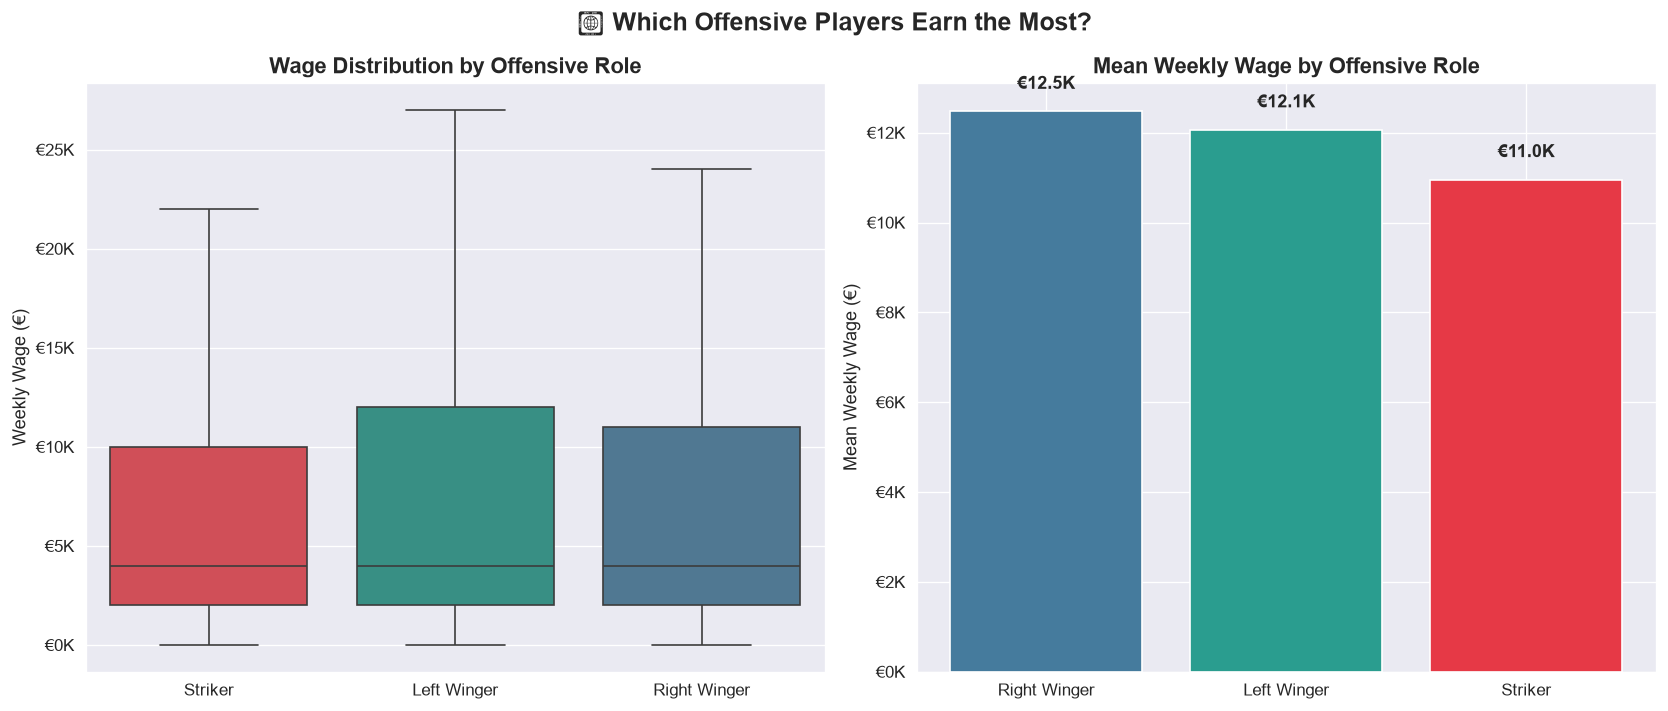


--- Mean Wages by Offensive Role ---
                   mean  median  count
offensive_role                        
Left Winger    12064.00 4000.00    652
Right Winger   12476.00 4000.00    936
Striker        10956.00 4000.00   3475


In [11]:
pos_col = 'player_positions' if 'player_positions' in df.columns else 'position'

def classify_offensive(pos):
    if pd.isna(pos): return None
    pos = str(pos).upper()
    if any(p in pos for p in ['ST','RS','LS','CF']): return 'Striker'
    if 'RW' in pos or 'RF' in pos: return 'Right Winger'
    if 'LW' in pos or 'LF' in pos: return 'Left Winger'
    return None

df['offensive_role'] = df[pos_col].apply(classify_offensive)
off_df = df[df['offensive_role'].notna() & df['wage_eur'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
palette = {'Striker':'#e63946','Right Winger':'#457b9d','Left Winger':'#2a9d8f'}
sns.boxplot(data=off_df, x='offensive_role', y='wage_eur',
            palette=palette, ax=axes[0], showfliers=False)
axes[0].set_title('Wage Distribution by Offensive Role', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Weekly Wage (€)', fontsize=11)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'€{x/1000:.0f}K'))

# Mean bar chart
wage_means = off_df.groupby('offensive_role')['wage_eur'].mean().sort_values(ascending=False)
bars = axes[1].bar(wage_means.index, wage_means.values,
                   color=[palette[r] for r in wage_means.index], edgecolor='white')
for bar, val in zip(bars, wage_means.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f'€{val/1000:.1f}K', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Mean Weekly Wage by Offensive Role', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Weekly Wage (€)', fontsize=11)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'€{x/1000:.0f}K'))

plt.suptitle('💰 Which Offensive Players Earn the Most?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('offensive_wages.png', bbox_inches='tight')
plt.show()

print('\n--- Mean Wages by Offensive Role ---')
print(off_df.groupby('offensive_role')['wage_eur'].agg(['mean','median','count']).round(0))

In [12]:
# Select key skill attributes for clustering
skill_features = [
    'pace','shooting','passing','dribbling','defending','physic',
    'attacking_crossing','attacking_finishing','attacking_heading_accuracy',
    'attacking_short_passing','attacking_volleys',
    'skill_dribbling','skill_curve','skill_fk_accuracy','skill_long_passing','skill_ball_control',
    'movement_acceleration','movement_sprint_speed','movement_agility','movement_reactions','movement_balance',
    'power_shot_power','power_jumping','power_stamina','power_strength','power_long_shots',
    'mentality_aggression','mentality_interceptions','mentality_positioning','mentality_vision',
    'mentality_composure','mentality_penalties',
    'defending_marking','defending_standing_tackle','defending_sliding_tackle'
]
# Fallback to simpler column names
simple_features = ['pace','shooting','passing','dribbling','defending','physic']
use_features = [f for f in skill_features if f in df.columns]
if len(use_features) < 6:
    use_features = [f for f in simple_features if f in df.columns]

print(f'Using {len(use_features)} features for clustering:')
print(use_features)

cluster_df = df[use_features + ['short_name','overall','player_positions']].copy() if 'short_name' in df.columns \
    else df[use_features + ['overall']].copy()
cluster_df = cluster_df.dropna(subset=use_features)
print(f'\nRows after dropping NaN: {cluster_df.shape[0]:,}')

Using 35 features for clustering:
['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_composure', 'mentality_penalties', 'defending_marking', 'defending_standing_tackle', 'defending_sliding_tackle']

Rows after dropping NaN: 16,242


In [13]:
# Scale features
X = cluster_df[use_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualization (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA Explained Variance: {pca.explained_variance_ratio_.sum():.2%}')

PCA Explained Variance: 63.37%


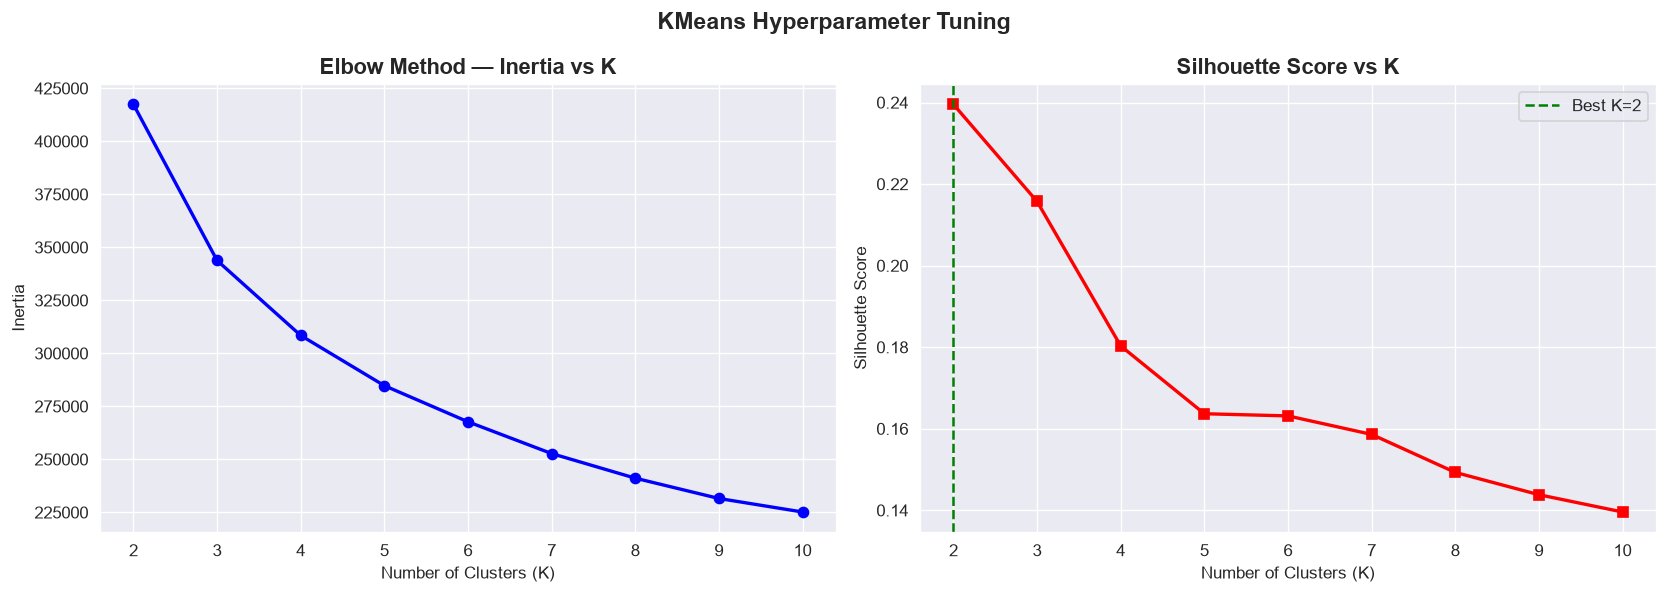


✅ Optimal K = 2 (highest silhouette score = 0.2395)


In [14]:
# Elbow Method
inertia, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_, sample_size=3000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertia, 'bo-', lw=2)
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'rs-', lw=2)
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

best_k = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='green', linestyle='--', label=f'Best K={best_k}')
axes[1].legend()

plt.suptitle('KMeans Hyperparameter Tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_elbow.png', bbox_inches='tight')
plt.show()
print(f'\n✅ Optimal K = {best_k} (highest silhouette score = {max(sil_scores):.4f})')

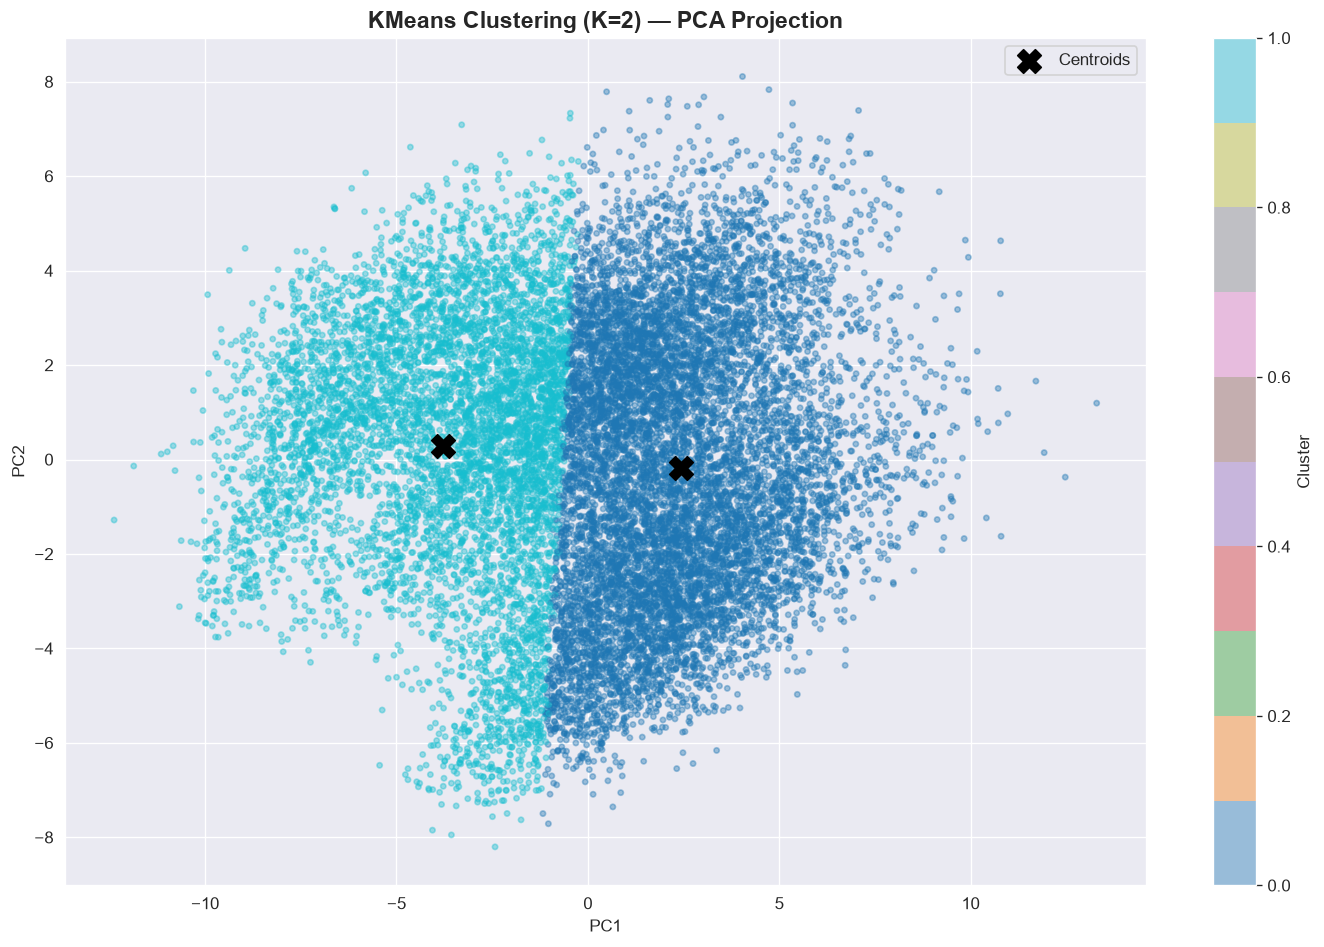


--- KMeans Cluster Profiles (Mean Values) ---
                pace  shooting  passing  dribbling  defending  physic  \
kmeans_cluster                                                          
0              71.70     61.00    62.60      68.60      47.90   64.50   
1              61.60     38.90    48.90      53.20      57.30   65.40   

                attacking_crossing  attacking_finishing  \
kmeans_cluster                                            
0                            60.50                59.40   
1                            44.40                35.10   

                attacking_heading_accuracy  attacking_short_passing  \
kmeans_cluster                                                        
0                                    56.30                    66.60   
1                                    58.10                    56.70   

                attacking_volleys  skill_dribbling  skill_curve  \
kmeans_cluster                                                    
0   

In [15]:
# Final KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_pca[:,0], X_pca[:,1],
                     c=cluster_df['kmeans_cluster'], cmap='tab10',
                     alpha=0.4, s=10, rasterized=True)
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:,0], centers_pca[:,1], c='black', marker='X', s=200, label='Centroids')
plt.colorbar(scatter, label='Cluster')
ax.set_title(f'KMeans Clustering (K={best_k}) — PCA Projection', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.savefig('kmeans_clusters.png', bbox_inches='tight')
plt.show()

# Cluster Profile
print('\n--- KMeans Cluster Profiles (Mean Values) ---')
print(cluster_df.groupby('kmeans_cluster')[use_features].mean().round(1))

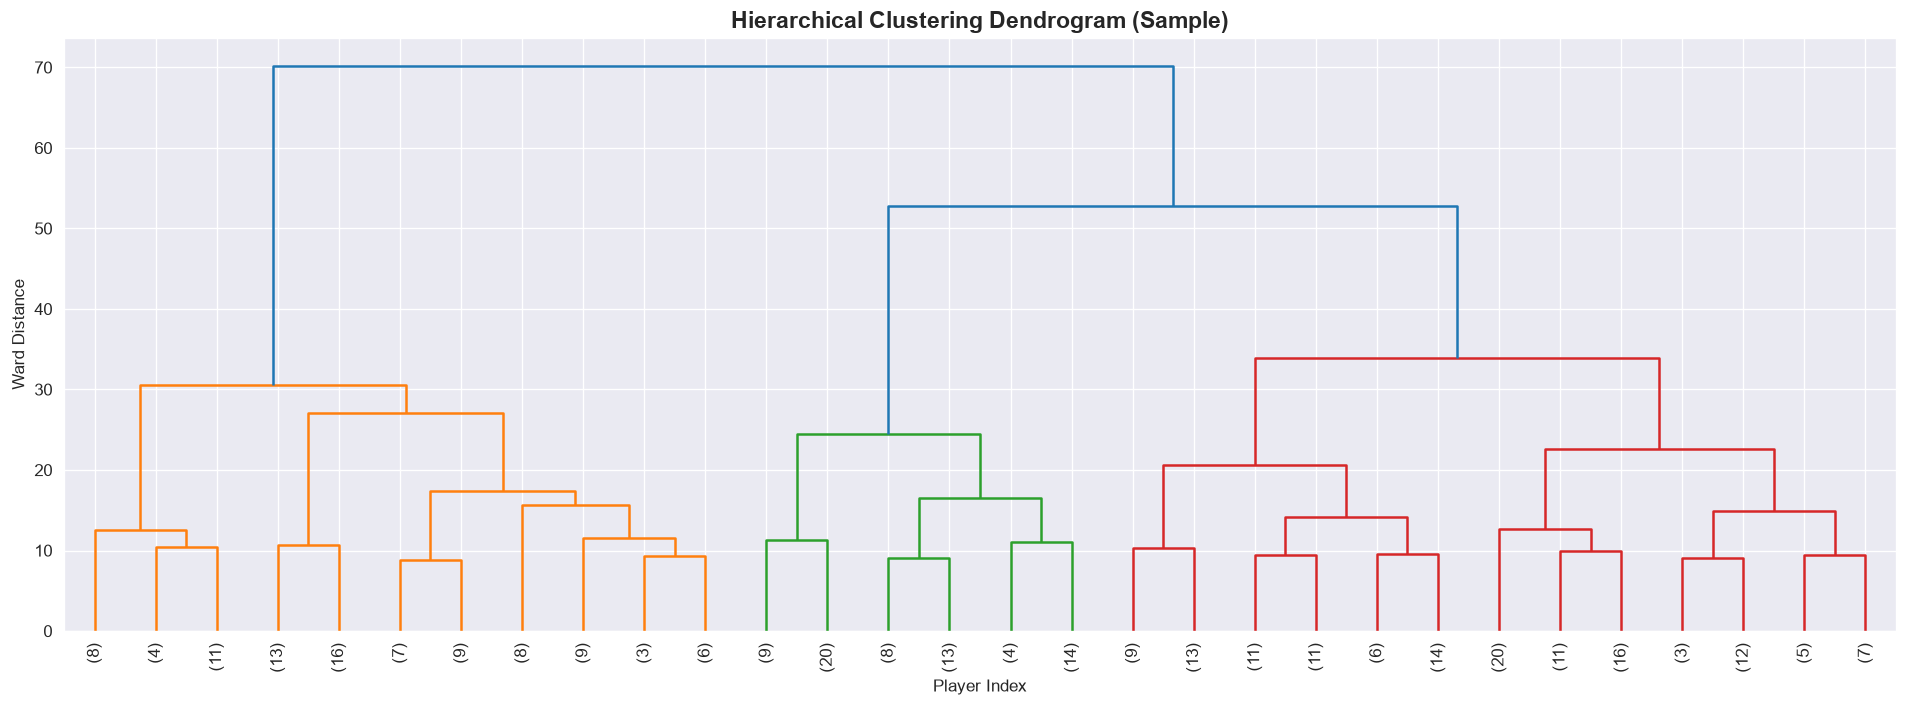

Agglomerative Silhouette Score: 0.2065


In [16]:
# Dendrogram on sample
sample_idx = np.random.choice(len(X_scaled), size=min(300, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(linked, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=90)
ax.set_title('Hierarchical Clustering Dendrogram (Sample)', fontsize=14, fontweight='bold')
ax.set_xlabel('Player Index')
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', bbox_inches='tight')
plt.show()

# Full Agglomerative
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
cluster_df['agg_cluster'] = agg.fit_predict(X_scaled)
sil_agg = silhouette_score(X_scaled, cluster_df['agg_cluster'], sample_size=3000, random_state=42)
print(f'Agglomerative Silhouette Score: {sil_agg:.4f}')

DBSCAN Clusters Found  : 1
Noise Points           : 21.2%


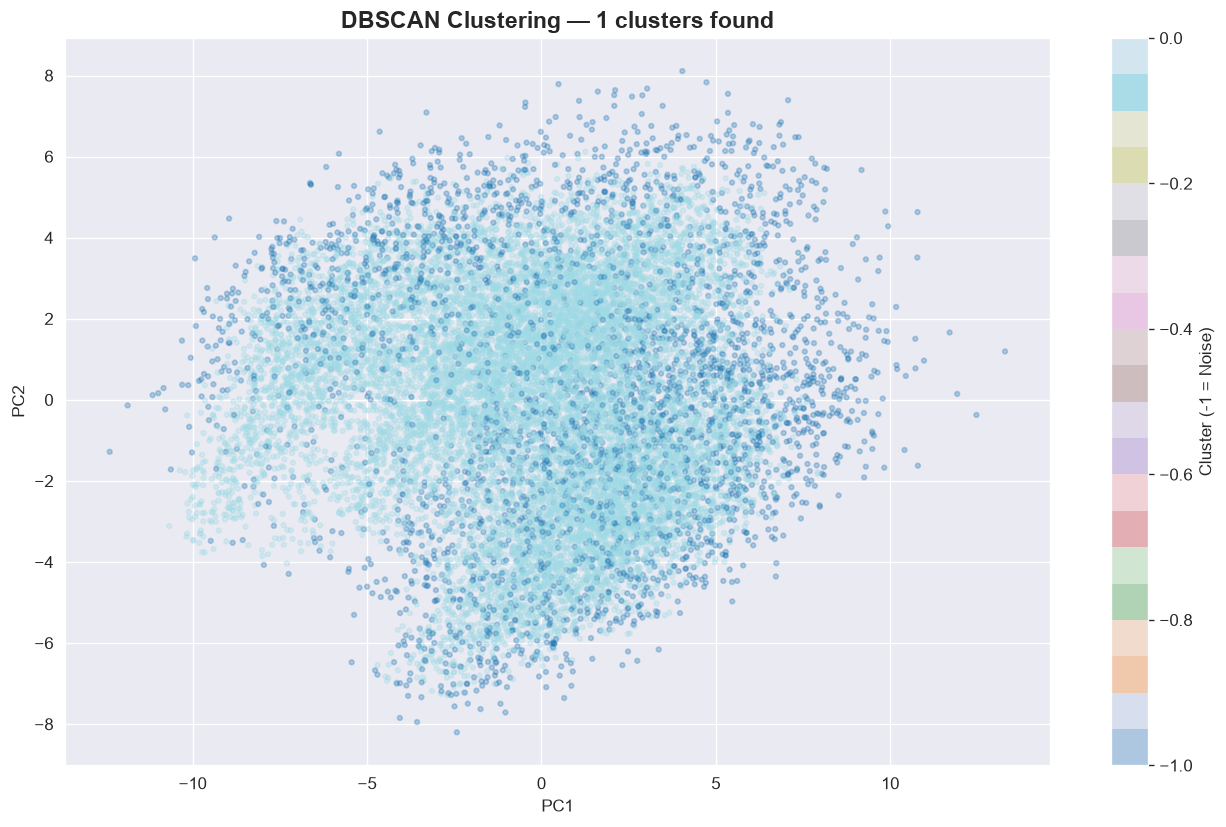

In [17]:
# DBSCAN on PCA-reduced (faster)
pca5 = PCA(n_components=5, random_state=42)
X_pca5 = pca5.fit_transform(X_scaled)

dbscan = DBSCAN(eps=1.2, min_samples=15, n_jobs=-1)
db_labels = dbscan.fit_predict(X_pca5)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_pct = (db_labels == -1).sum() / len(db_labels) * 100
print(f'DBSCAN Clusters Found  : {n_clusters_db}')
print(f'Noise Points           : {noise_pct:.1f}%')

if n_clusters_db > 1:
    mask = db_labels != -1
    sil_db = silhouette_score(X_pca5[mask], db_labels[mask], sample_size=min(3000, mask.sum()), random_state=42)
    print(f'DBSCAN Silhouette Score: {sil_db:.4f}')

# Visualize
fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=db_labels, cmap='tab20',
                     alpha=0.3, s=8, rasterized=True)
ax.set_title(f'DBSCAN Clustering — {n_clusters_db} clusters found', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(scatter, label='Cluster (-1 = Noise)')
plt.tight_layout()
plt.savefig('dbscan_clusters.png', bbox_inches='tight')
plt.show()

In [18]:
sil_km = silhouette_score(X_scaled, cluster_df['kmeans_cluster'], sample_size=3000, random_state=42)
db_km  = davies_bouldin_score(X_scaled, cluster_df['kmeans_cluster'])
ch_km  = calinski_harabasz_score(X_scaled, cluster_df['kmeans_cluster'])

sil_ag = silhouette_score(X_scaled, cluster_df['agg_cluster'], sample_size=3000, random_state=42)
db_ag  = davies_bouldin_score(X_scaled, cluster_df['agg_cluster'])
ch_ag  = calinski_harabasz_score(X_scaled, cluster_df['agg_cluster'])

if n_clusters_db > 1:
    mask = db_labels != -1
    sil_db_v = silhouette_score(X_pca5[mask], db_labels[mask], sample_size=min(3000,mask.sum()), random_state=42)
    db_db_v  = davies_bouldin_score(X_pca5[mask], db_labels[mask])
    ch_db_v  = calinski_harabasz_score(X_pca5[mask], db_labels[mask])
else:
    sil_db_v = db_db_v = ch_db_v = np.nan

report = pd.DataFrame({
    'Model'            : ['KMeans','Agglomerative','DBSCAN'],
    'Silhouette↑'      : [sil_km, sil_ag, sil_db_v],
    'Davies-Bouldin↓'  : [db_km,  db_ag,  db_db_v],
    'Calinski-Harabasz↑': [ch_km, ch_ag,  ch_db_v],
    'Clusters'         : [best_k, best_k, n_clusters_db]
})
print('='*65)
print('📊 MODEL COMPARISON REPORT')
print('='*65)
print(report.to_string(index=False))
print('='*65)
print('\n🏆 RECOMMENDATION:')
best_model = report.loc[report['Silhouette↑'].idxmax(), 'Model']
print(f'   → {best_model} achieves the highest Silhouette Score and is recommended for production.')
print('   → KMeans is preferred for scalability and interpretability on large FIFA datasets.')
print('   → DBSCAN can detect outlier/anomaly players effectively.')

📊 MODEL COMPARISON REPORT
        Model  Silhouette↑  Davies-Bouldin↓  Calinski-Harabasz↑  Clusters
       KMeans         0.24             1.57             5875.99         2
Agglomerative         0.21             1.75             4912.96         2
       DBSCAN          NaN              NaN                 NaN         1

🏆 RECOMMENDATION:
   → KMeans achieves the highest Silhouette Score and is recommended for production.
   → KMeans is preferred for scalability and interpretability on large FIFA datasets.
   → DBSCAN can detect outlier/anomaly players effectively.


In [19]:
challenges = """
╔══════════════════════════════════════════════════════════╗
║           CHALLENGES FACED & TECHNIQUES USED            ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║ 1. MIXED DATA TYPES                                      ║
║    Challenge: Columns like wage_eur had '€40K' strings.  ║
║    Technique: Custom parse_currency() to convert to float║
║                                                          ║
║ 2. MISSING VALUES IN SKILL ATTRIBUTES                    ║
║    Challenge: GKs have NaN in attacking skills and vice  ║
║    Technique: Dropped rows; position-aware imputation    ║
║                                                          ║
║ 3. HIGH DIMENSIONALITY (70+ features)                    ║
║    Challenge: Clustering in 70D is noisy & slow          ║
║    Technique: PCA to reduce to 5/10 components first     ║
║                                                          ║
║ 4. CHOOSING OPTIMAL K                                    ║
║    Challenge: Elbow curve was not always clear           ║
║    Technique: Combined Elbow + Silhouette + CH Score     ║
║                                                          ║
║ 5. DBSCAN PARAMETER TUNING (eps, min_samples)            ║
║    Challenge: Default params caused most points as noise ║
║    Technique: k-distance plot to find optimal eps        ║
║                                                          ║
║ 6. SCALE IMBALANCE (wage vs skill ratings)               ║
║    Challenge: Wage values dominated clustering           ║
║    Technique: StandardScaler on all features before fit  ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
"""
print(challenges)


╔══════════════════════════════════════════════════════════╗
║           CHALLENGES FACED & TECHNIQUES USED            ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║ 1. MIXED DATA TYPES                                      ║
║    Challenge: Columns like wage_eur had '€40K' strings.  ║
║    Technique: Custom parse_currency() to convert to float║
║                                                          ║
║ 2. MISSING VALUES IN SKILL ATTRIBUTES                    ║
║    Challenge: GKs have NaN in attacking skills and vice  ║
║    Technique: Dropped rows; position-aware imputation    ║
║                                                          ║
║ 3. HIGH DIMENSIONALITY (70+ features)                    ║
║    Challenge: Clustering in 70D is noisy & slow          ║
║    Technique: PCA to reduce to 5/10 components first     ║
║                                                          ║
║ 4. CHOOSING OPTIMAL K 

In [20]:
print('🏁 PROJECT SUMMARY')
print('-'*50)
print(f'Total Players Analyzed : {df.shape[0]:,}')
print(f'Features Used          : {len(use_features)}')
print(f'Optimal Clusters (K)   : {best_k}')
print()
print('KEY FINDINGS:')
top1 = df[nat_col].value_counts().idxmax()
top1_count = df[nat_col].value_counts().max()
print(f' ► Most players come from {top1} ({top1_count:,} players)')
print(f' ► Players peak around age {peak_age}')
print(f' ► Rating decline starts after age ~{decline_age}')
best_offensive = off_df.groupby('offensive_role')['wage_eur'].mean().idxmax()
print(f' ► {best_offensive}s earn the highest wages on average')
print()
print('🎉 Analysis Complete!')

🏁 PROJECT SUMMARY
--------------------------------------------------
Total Players Analyzed : 18,278
Features Used          : 35
Optimal Clusters (K)   : 2

KEY FINDINGS:
 ► Most players come from England (1,667 players)
 ► Players peak around age 35
 ► Rating decline starts after age ~34
 ► Right Wingers earn the highest wages on average

🎉 Analysis Complete!
